# Praktyczne wprowadzenie do Deep Learningu w Pythonie

W tym pliku pokazano jakie są kolejne kroki uczenia maszynowego. Naszym celem jest wytrenowanie modelu - sieci neuronowej - by umiał "odczytać" samodzielnie jaka cyfra zapisana jest na obrazie.

In [ ]:
#importowanie niezbędnych modułów
import tensorflow as tf #do tworzenia modeli machine learning (uczenia maszynowego)
import numpy as np #operacje na macierzach
import matplotlib.pyplot as plt #wykresy
import seaborn as sns #wykresy
from sklearn.metrics import confusion_matrix #macierz pomyłek (dla modelu)

więcej informacji na temat tensorflow: https://www.tensorflow.org/learn?hl=pl

# Podstawowe informacje na temat zbioru, podział na treningowy i testowy

Korzytsamy ze zbioru danych MNIST. Zawiera on 70 000 obrazów o wymiarach 28x28 pikseli. Przedstawia ręcznie zapisane cyfry od 0 do 9.
- każdy obrazek ma przypisaną etykietę (label)
 - 10 etykiet (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
- podzielony jest na zbiór treningowy (60 000 obrazów) oraz testowy (10 000 obrazów)

Pracując na "własnym" zbiorze (np. obrazy plazmidów) należy pamiętać o poprawnym podziale danych na testowe i treningowe. Nie może dojść do sytuacji w której te same dane znajdują się w obu zbiorach - przeuczenie modelu. Dodatkowo, należy pamiętać o zbalansowaniu klas. Przykładowo stosunek każdej z klas w obu zbiorach powinien pozstać taki sam.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
rozmiar zbioru treningowego: (60000, 28, 28)
rozmiar zbioru testowego: (10000, 28, 28)
labele zbioru treningowego (liczba): (60000,)
labele zbioru testowego (liczba): (10000,)
unikalne labele: [0 1 2 3 4 5 6 7 8 9]


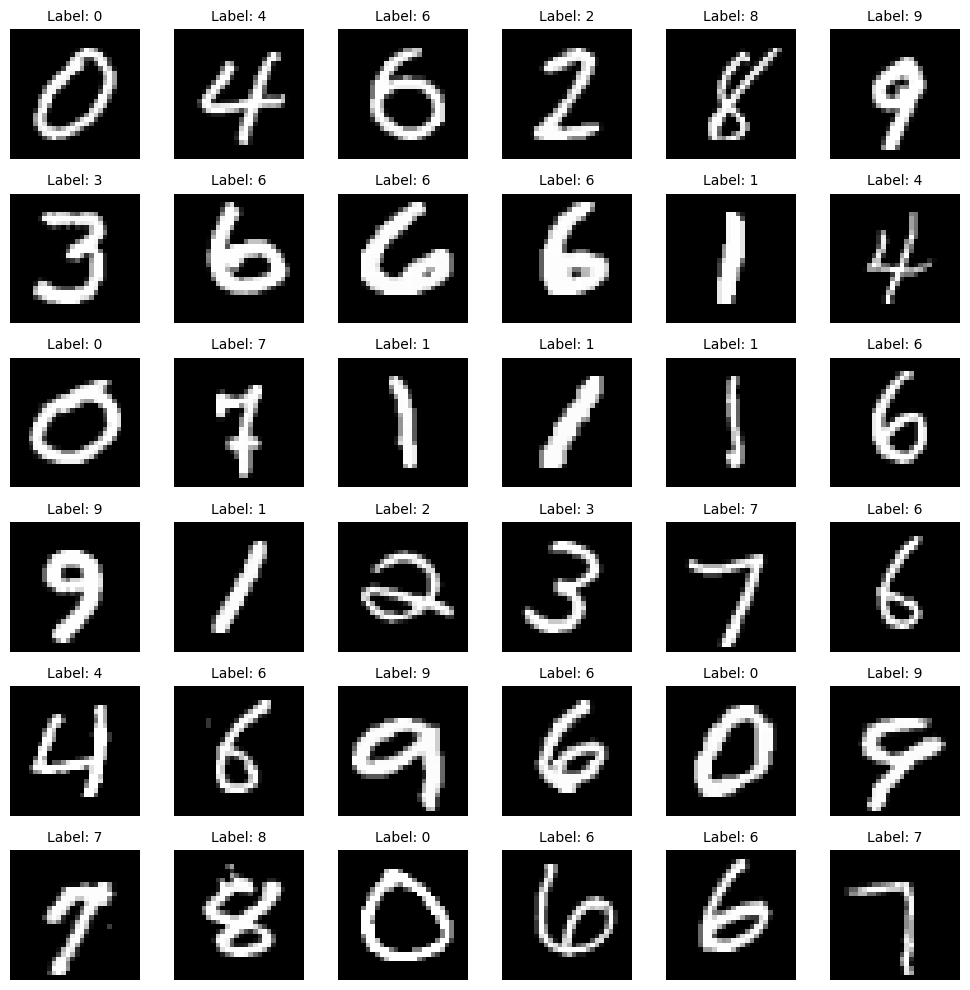

In [ ]:
#wczytanie zbioru MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
#x_train -> obrazy treningowe
#y_train -> labele obrazów treningowych
#x_test-> obrazy testowe
#y_test -> labele obrazów testowych



print(f"rozmiar zbioru treningowego: {x_train.shape}")
print(f"rozmiar zbioru testowego: {x_test.shape}")
#liczba zdjęć w zbiorze, rozdzielczosć zdjęć (28x28) -> są to obrazy w skali szarości

print(f"labele zbioru treningowego (liczba): {y_train.shape}")
print(f"labele zbioru testowego (liczba): {y_test.shape}")
#liczba labeli w zbiorze - powinna odpowiadać liczbie zdjęć

print(f"unikalne labele: {np.unique(y_train)}")
#od 0 do 9

#wizualizacja 36 losowych zdjęć ze zbioru treningowego
random_id = np.random.randint(0, x_train.shape[0], 36)
fig, axes = plt.subplots(6, 6, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[random_id[i]], cmap='gray')
    ax.set_title(f"Label: {y_train[random_id[i]]}", fontsize = 10)
    ax.axis('off')
plt.tight_layout()
plt.show()




# Architektura modelu

Każdy model można podzielić na 3 główne warstwy:
1. Warstwa wejściowa - musi odpowiadać formatowi naszych danych wejściowych
2. Warstwy ukryte - to tutaj neurony uczą się i szukają wzorców na dostarczonych danych. Określamy tu liczbę neuronów i funkcję aktywacji.
3. Warstwa wyjściowa - musi mieć tyle neuronów ile klas jest dostęnych. Wykurzystujemy tu funkcję Softmax - by końcowo otrzymać prawdopobieństwo dla każdej z cyfr sumujące się do 100%.



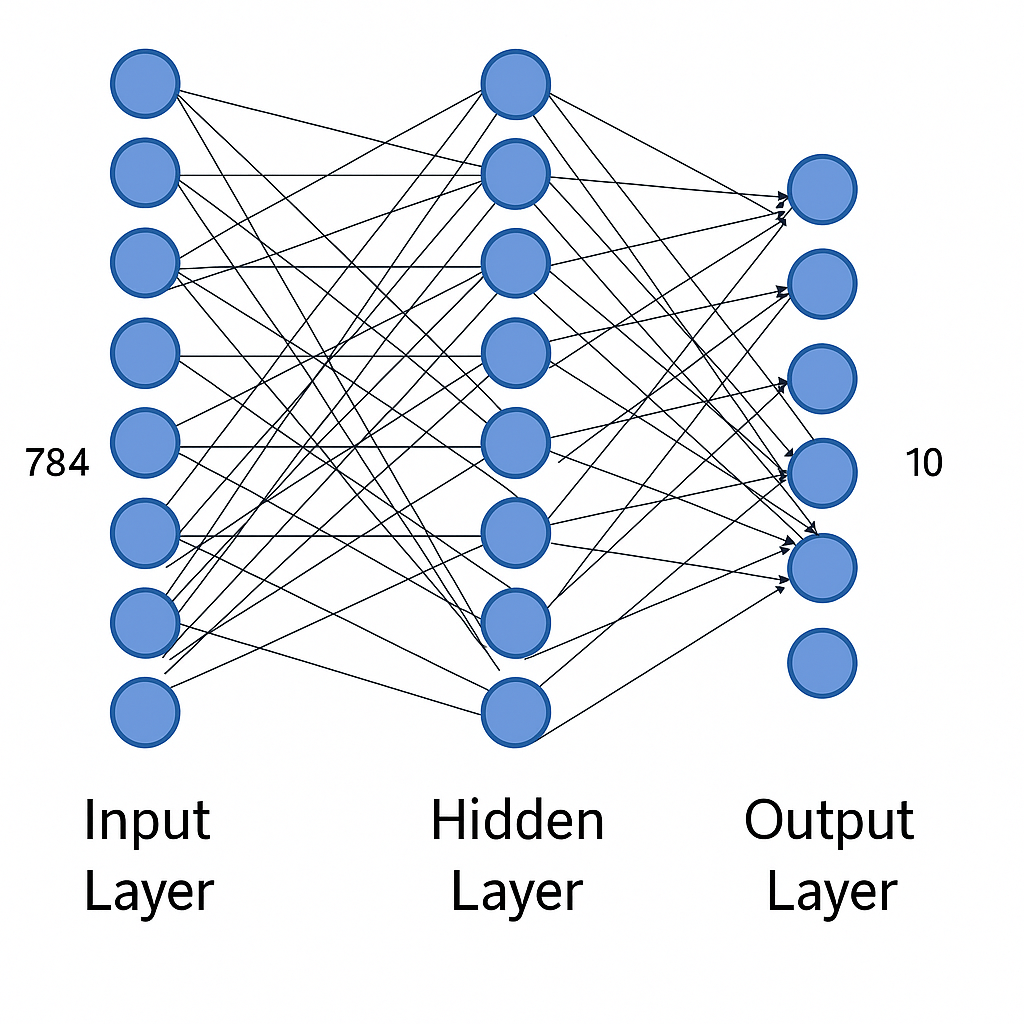

In [ ]:
#normalizacja
x_train = x_train / 255.0
x_test = x_test / 255.0
#zakres wartości przed: [0, 255]
#zakres po: [0, 1]


#zbudowanie modelu - wybranie jego architektury
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),#spłaszczenie danych -> z 28x28 do 784x1
    tf.keras.layers.Dense(128, activation='relu'), #wartstwa ukryta -> 128 neuronów + funkcja aktywacji
    tf.keras.layers.Dense(10, activation='softmax') #wartstwa wyjściowa -> 10 neuronów dla 10 klas + funkcja aktywacji
])

#komiplacja modelu
model.compile(optimizer='adam', #aktualizacja wag w sieci
              loss='sparse_categorical_crossentropy',#ocena jak bardzo myli się model
              metrics=['accuracy'])#metryka pozwalająca na ocenę jakości modelu

#tredning modelu -> zbiór trningowy (obrazki i labele) + liczba epok (ile razy sieć "przejdzie" przez wszytskie dane)
#liczbę epok możemy modyfikować w zależności od potrzeb
model.fit(x_train, y_train, epochs=5)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9247 - loss: 0.2619
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9661 - loss: 0.1141
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9766 - loss: 0.0792
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9817 - loss: 0.0607
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9856 - loss: 0.0470


# Ewaluacja modelu

Po treningu otrzymujemy model z daną funkcjonalnością - tu przewiduje jaką cyfrę przedstawia obrazek.
Jakość modelu możemy ocenić wykorzystując zbiór testowy. Do ewauacji wykorzystujemy metryki takie jak np.:
*   accuracy - dokładność (w ilu procentach model przewidział poprawnie)
* precision - precycja
* recall - czułość

Możemy wizualizować przewidywania z wykorzystaniem macierzy pomyłek (confusion matrix). Jest to macierz o wymiarch odpowiadających liczbie klas (tu 10x10). Pozwala to na dostrzeżenie w jakich sytuacjach model się myli.

Wytrenowany, przetestowany model możemy wykorzystać jako narzędzie będące częścią większej całości.



313/313 - 1s - 2ms/step - accuracy: 0.9787 - loss: 0.0717
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


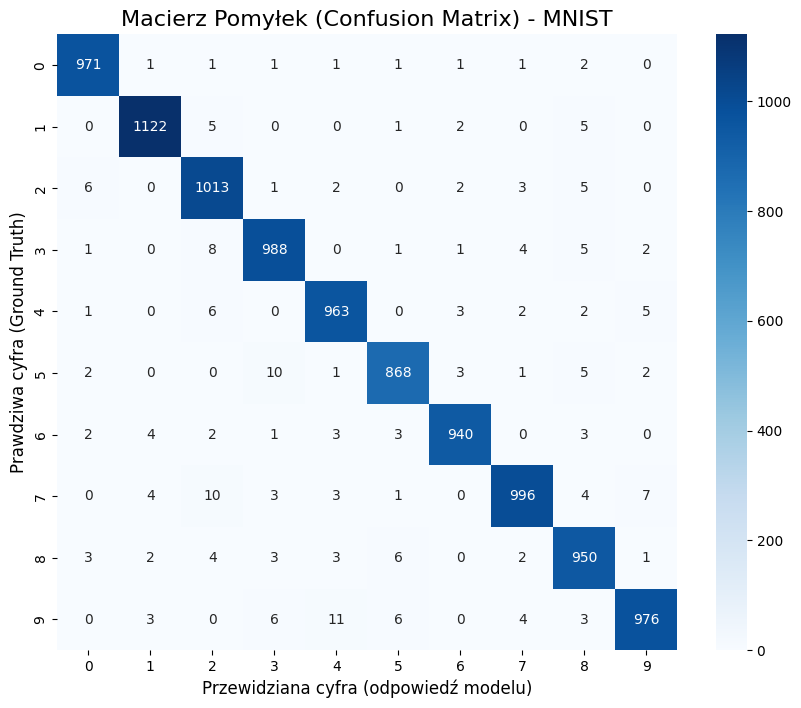

In [ ]:
#testowanie modelu -> jak radzi sobie z danymi, których nie widział (testowe)
loss, accuracy = model.evaluate(x_test,  y_test, verbose=2)


#dodatkowo, do wizualizacji macierz pomyłek
predykcje_prawdopodobienstwa = model.predict(x_test)
y_pred = np.argmax(predykcje_prawdopodobienstwa, axis=1)
cm = confusion_matrix(y_test, y_pred)


#wykres (heatmapa) przedstawiający macierz pomyłek
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Przewidziana cyfra (odpowiedź modelu)', fontsize=12)
plt.ylabel('Prawdziwa cyfra (Ground Truth)', fontsize=12)
plt.title('Macierz Pomyłek (Confusion Matrix) - MNIST', fontsize=16)
plt.show()

# Problem w kontekście naszego projektu

Mamy obrazy plazmidów i w celu analizy ich chcielibyśmy oddzielić je od tła (segmentacja). Można to zrobić ręcznie, jednak jest to prachłonne, czasochłonne i wymaga obecności eksperta.

Takim ekspertem może zostac model - będzie przeiwdywał co na zdjęciu jest plazmidem, a co tłem. Do treningu i ewaluacji modelu potrzeba jednak labeli - by model miał w ogóle na czym się uczyć.

Problem naszej segmentacji jest problemem binarnym - ma 2 klasy - tło i plazmid. Labelami nie będą cyfry, a binarne maski. Architektura modelu będzię nieco inna i bardziej złożona.

**U-net** - architektura do analizyu obrazów.



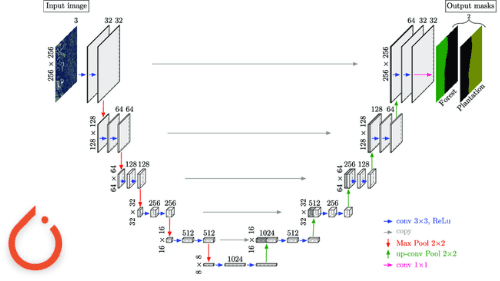

Źródła grafik:

https://medium.com/@renjiniag/understanding-multilayer-perceptrons-through-mnist-digit-classification-54463c74c35e

https://pyimagesearch.com/2021/11/08/u-net-training-image-segmentation-models-in-pytorch/